Shape: (1338, 7)
Columns: Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')
   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520

Missing Values:
 age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


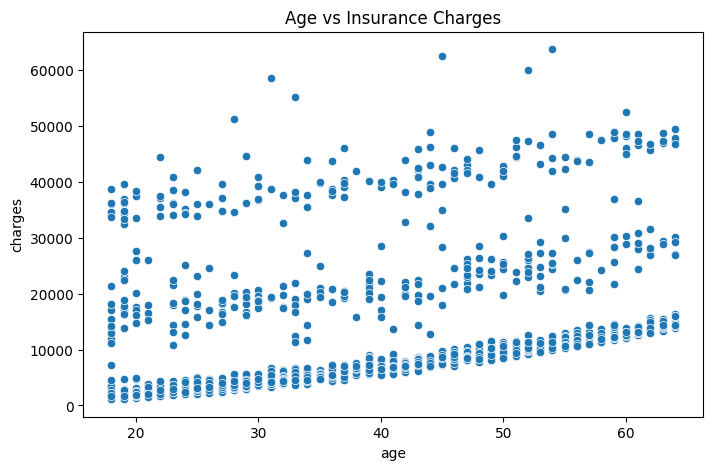

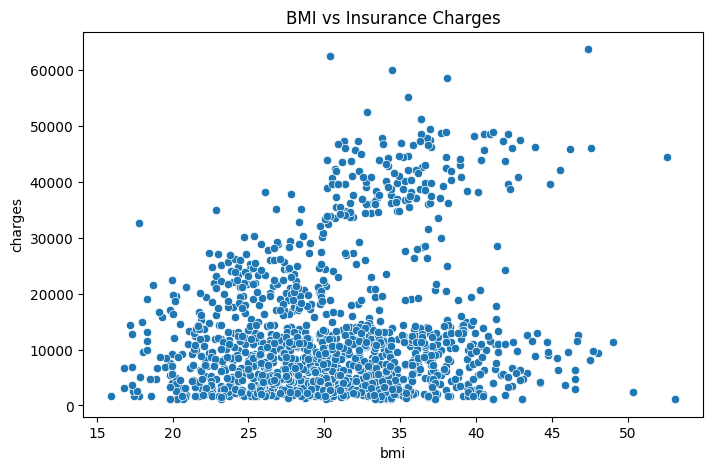

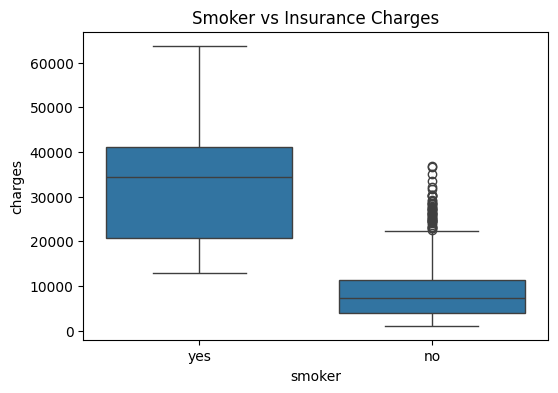


MAE: 4181.19447375365
RMSE: 5796.284659276273


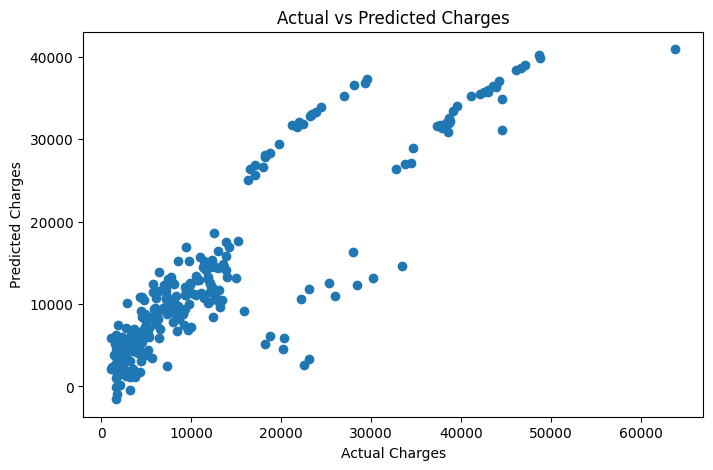

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Load dataset
df = pd.read_csv("insurance.csv")

print("Shape:", df.shape)
print("Columns:", df.columns)
print(df.head())

# Check missing values
print("\nMissing Values:\n", df.isnull().sum())

# EDA Visualizations
plt.figure(figsize=(8,5))
sns.scatterplot(x="age", y="charges", data=df)
plt.title("Age vs Insurance Charges")
plt.show()

plt.figure(figsize=(8,5))
sns.scatterplot(x="bmi", y="charges", data=df)
plt.title("BMI vs Insurance Charges")
plt.show()

plt.figure(figsize=(6,4))
sns.boxplot(x="smoker", y="charges", data=df)
plt.title("Smoker vs Insurance Charges")
plt.show()

# Encoding categorical variables
df = pd.get_dummies(df, drop_first=True)

# Split features and target
X = df.drop("charges", axis=1)
y = df["charges"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Evaluation
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("\nMAE:", mae)
print("RMSE:", rmse)

# Actual vs Predicted graph
plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred)
plt.title("Actual vs Predicted Charges")
plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.show()